# 04 模型训练与 GBDT 模型对比

## 建模目标

本 notebook 的目标是基于用户过去 7 天行为特征，预测用户在 prediction_date 当天是否发生购买行为。

这是一个典型的类别不平衡二分类任务：

- label = 1：用户在 prediction_date 当天购买；
- label = 0：用户在 prediction_date 当天未购买。

因此，本 notebook 不以 Accuracy 作为核心指标，而重点关注：

1. AUC；
2. PR-AUC；
3. Top-K purchase rate；
4. Recall@K；
5. Lift@K；
6. 基于预测排序的收益模拟。

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

os.makedirs("../outputs/tables", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)

In [2]:
# 1. 读取建模样本
model_data_path = "../data/processed/model_data_user_level_7d.csv"

model_data = pd.read_csv(model_data_path)

model_data["prediction_date"] = pd.to_datetime(model_data["prediction_date"])

In [3]:
# 2. 特征列与时间切分
exclude_cols = [
    "user_id",
    "prediction_date",
    "label"
]

feature_cols = [
    col for col in model_data.columns
    if col not in exclude_cols
]

unique_dates = sorted(model_data["prediction_date"].unique())

print("预测日期数量:", len(unique_dates))
print("所有预测日期:")
print(unique_dates)

n_dates = len(unique_dates)
test_date_count = max(1, int(np.ceil(n_dates * 0.3)))

test_dates = unique_dates[-test_date_count:]
train_dates = unique_dates[:-test_date_count]

train_data = model_data[
    model_data["prediction_date"].isin(train_dates)
].copy()

test_data = model_data[
    model_data["prediction_date"].isin(test_dates)
].copy()

print("\n训练集日期范围:", train_data["prediction_date"].min(), "至", train_data["prediction_date"].max())
print("测试集日期范围:", test_data["prediction_date"].min(), "至", test_data["prediction_date"].max())

print("\n训练集维度:", train_data.shape)
print("测试集维度:", test_data.shape)

print("\n训练集正样本比例:", train_data["label"].mean())
print("测试集正样本比例:", test_data["label"].mean())

预测日期数量: 8
所有预测日期:
[Timestamp('2019-10-08 00:00:00'), Timestamp('2019-10-09 00:00:00'), Timestamp('2019-10-10 00:00:00'), Timestamp('2019-10-11 00:00:00'), Timestamp('2019-10-12 00:00:00'), Timestamp('2019-10-13 00:00:00'), Timestamp('2019-10-14 00:00:00'), Timestamp('2019-10-15 00:00:00')]

训练集日期范围: 2019-10-08 00:00:00 至 2019-10-12 00:00:00
测试集日期范围: 2019-10-13 00:00:00 至 2019-10-15 00:00:00

训练集维度: (5009719, 35)
测试集维度: (3169168, 35)

训练集正样本比例: 0.010286405285406227
测试集正样本比例: 0.0116084095257809


In [4]:
# 3. 构造 X / y 与类别权重
# 购买用户占比较低，因此训练时需要提高模型对正样本的关注
X_train = train_data[feature_cols].copy().fillna(0)
y_train = train_data["label"].copy()

X_test = test_data[feature_cols].copy().fillna(0)
y_test = test_data["label"].copy()

pos_count = y_train.sum()
neg_count = len(y_train) - pos_count

scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0

print("正样本数量:", pos_count)
print("负样本数量:", neg_count)
print("scale_pos_weight:", scale_pos_weight)

正样本数量: 51532
负样本数量: 4958187
scale_pos_weight: 96.2156912209889


In [5]:
# 4. 评估函数
def evaluate_auc_pr(y_true, pred_prob, model_name):
    """
    计算模型的 AUC 和 PR-AUC。

    AUC：
        衡量模型整体排序能力。
        可以理解为随机抽一个购买用户和一个未购买用户，
        模型把购买用户排在前面的概率。

    PR-AUC：
        衡量模型在类别不平衡场景下识别正样本的能力。
        由于购买用户占比较低，PR-AUC 比 Accuracy 更有参考价值。
    """

    if len(np.unique(y_true)) < 2:
        auc_value = np.nan
        pr_auc_value = np.nan
    else:
        auc_value = roc_auc_score(y_true, pred_prob)
        pr_auc_value = average_precision_score(y_true, pred_prob)

    return {
        "model": model_name,
        "AUC": auc_value,
        "PR_AUC": pr_auc_value
    }


def evaluate_topk(y_true, pred_prob, k=0.1):
    """
    计算 Top-K 用户购买率、Recall@K 和 Lift@K。

    Top-K purchase rate：
        模型预测分数最高的前 K% 用户中的真实购买率。

    Recall@K：
        Top-K 用户覆盖了全部真实购买用户中的多少比例。

    Lift@K：
        Top-K 用户购买率 / 整体购买率。
        用于衡量模型筛选人群相对于随机触达的提升倍数。
    """

    eval_df = pd.DataFrame({
        "label": np.array(y_true),
        "pred_prob": np.array(pred_prob)
    })

    eval_df = eval_df.sort_values(
        "pred_prob",
        ascending=False
    ).reset_index(drop=True)

    top_k_n = max(1, int(len(eval_df) * k))
    top_k_df = eval_df.head(top_k_n)

    overall_purchase_rate = eval_df["label"].mean()
    topk_purchase_rate = top_k_df["label"].mean()

    total_positive = eval_df["label"].sum()
    topk_positive = top_k_df["label"].sum()

    recall_at_k = (
        topk_positive / total_positive
        if total_positive > 0
        else 0
    )

    lift_at_k = (
        topk_purchase_rate / overall_purchase_rate
        if overall_purchase_rate > 0
        else 0
    )

    return {
        "top_k": k,
        "top_k_n": top_k_n,
        "overall_purchase_rate": overall_purchase_rate,
        "topk_purchase_rate": topk_purchase_rate,
        "recall_at_k": recall_at_k,
        "lift_at_k": lift_at_k
    }

In [6]:
# 5. 模型训练
models = {}

# Logistic Regression baseline
models["Logistic Regression"] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

# LightGBM
models["LightGBM"] = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

# XGBoost
models["XGBoost"] = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# CatBoost
models["CatBoost"] = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1, scale_pos_weight],
    random_seed=42,
    verbose=False
)

pred_results = {}
eval_records = []

for model_name, model in models.items():
    print(f"\n开始训练模型: {model_name}")

    model.fit(X_train, y_train)

    pred_prob = model.predict_proba(X_test)[:, 1]

    pred_results[model_name] = {
        "model": model,
        "pred_prob": pred_prob
    }

    eval_record = evaluate_auc_pr(
        y_true=y_test,
        pred_prob=pred_prob,
        model_name=model_name
    )

    eval_records.append(eval_record)

    print(eval_record)

model_eval_results = pd.DataFrame(eval_records).sort_values(
    "PR_AUC",
    ascending=False
)

display(model_eval_results)

model_eval_results.to_csv(
    "../outputs/tables/model_eval_results.csv",
    index=False,
    encoding="utf-8-sig"
)


开始训练模型: Logistic Regression
{'model': 'Logistic Regression', 'AUC': np.float64(0.8024652346884007), 'PR_AUC': np.float64(0.1002742267864965)}

开始训练模型: LightGBM
[LightGBM] [Info] Number of positive: 51532, number of negative: 4958187
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.093529 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4103
[LightGBM] [Info] Number of data points in the train set: 5009719, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010286 -> initscore=-4.566592
[LightGBM] [Info] Start training from score -4.566592
{'model': 'LightGBM', 'AUC': np.float64(0.8126881142661495), 'PR_AUC': np.float64(0.12915163075583572)}

开始训练模型: XGBoost
{'model': 'XGBoost', 'AUC': np.float64(0.813956220447871), 'PR_AUC': np.float64(0.13059118300444117)}

开始训练模型: CatBoost
{'model': 'CatBoost', 'AUC': np.floa

,model,AUC,PR_AUC
2,XGBoost,0.813956,0.130591
1,LightGBM,0.812688,0.129152
3,CatBoost,0.813681,0.127708
0,Logistic Regression,0.802465,0.100274


In [7]:
# 6. Top-K 业务指标
topk_list = [0.05, 0.10, 0.20, 0.30]

topk_records = []

for model_name, item in pred_results.items():
    pred_prob = item["pred_prob"]

    for k in topk_list:
        record = evaluate_topk(
            y_true=y_test,
            pred_prob=pred_prob,
            k=k
        )

        record["model"] = model_name
        topk_records.append(record)

all_models_topk_results = pd.DataFrame(topk_records)

display(all_models_topk_results)

all_models_topk_results.to_csv(
    "../outputs/tables/all_models_topk_results.csv",
    index=False,
    encoding="utf-8-sig"
)

top10_model_compare = (
    all_models_topk_results[all_models_topk_results["top_k"] == 0.10]
    .sort_values("topk_purchase_rate", ascending=False)
)

display(top10_model_compare)

top10_model_compare.to_csv(
    "../outputs/tables/top10_model_compare.csv",
    index=False,
    encoding="utf-8-sig"
)

,top_k,top_k_n,overall_purchase_rate,topk_purchase_rate,recall_at_k,lift_at_k,model
0,0.05,158458,0.011608,0.083713,0.360570,7.211413,Logistic Regression
1,0.10,316916,0.011608,0.059489,0.512463,5.124643,Logistic Regression
2,0.20,633833,0.011608,0.039196,0.675311,3.376556,Logistic Regression
3,0.30,950750,0.011608,0.029506,0.762538,2.541793,Logistic Regression
4,0.05,158458,0.011608,0.091406,0.393705,7.874113,LightGBM
5,0.10,316916,0.011608,0.062124,0.535160,5.351613,LightGBM
6,0.20,633833,0.011608,0.040004,0.689228,3.446142,LightGBM
7,0.30,950750,0.011608,0.029763,0.769170,2.563902,LightGBM
8,0.05,158458,0.011608,0.091658,0.394792,7.895858,XGBoost
9,0.10,316916,0.011608,0.062237,0.536139,5.361399,XGBoost


,top_k,top_k_n,overall_purchase_rate,topk_purchase_rate,recall_at_k,lift_at_k,model
13,0.1,316916,0.011608,0.062433,0.537824,5.378252,CatBoost
9,0.1,316916,0.011608,0.062237,0.536139,5.361399,XGBoost
5,0.1,316916,0.011608,0.062124,0.535160,5.351613,LightGBM
1,0.1,316916,0.011608,0.059489,0.512463,5.124643,Logistic Regression


In [8]:
# 7. 保存测试集预测结果
test_prediction_results = test_data[
    ["user_id", "prediction_date", "label"]
].copy()

for model_name, item in pred_results.items():
    col_name = (
        "pred_prob_"
        + model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    test_prediction_results[col_name] = item["pred_prob"]

display(test_prediction_results.head())

test_prediction_results.to_csv(
    "../outputs/tables/test_prediction_results.csv",
    index=False,
    encoding="utf-8-sig"
)

,user_id,prediction_date,label,pred_prob_logistic_regression,pred_prob_lightgbm,pred_prob_xgboost,pred_prob_catboost
5009719,195082191,2019-10-13,0,0.256135,0.165845,0.165686,0.163152
5009720,200673532,2019-10-13,0,0.480340,0.492412,0.545160,0.547670
5009721,205053188,2019-10-13,0,0.240579,0.164986,0.176184,0.181820
5009722,216064734,2019-10-13,0,0.259218,0.232996,0.245196,0.252208
5009723,222907508,2019-10-13,0,0.173663,0.224818,0.197452,0.191004


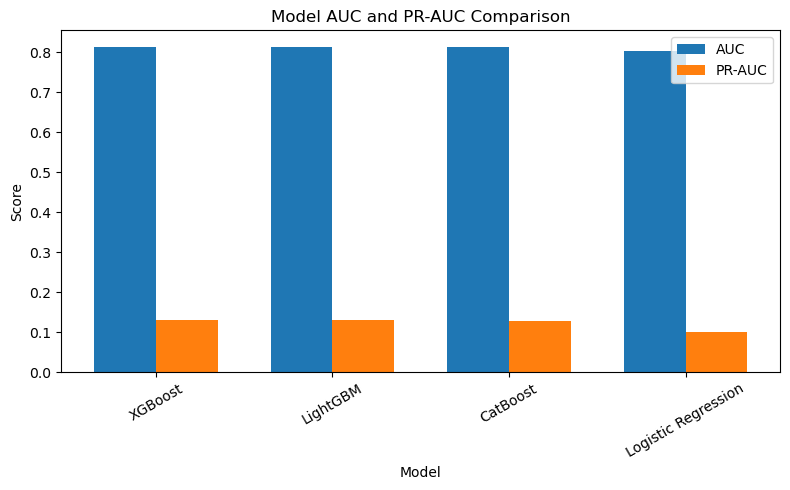

In [9]:
# 8. AUC / PR-AUC 对比图
plt.figure(figsize=(8, 5))

x = np.arange(len(model_eval_results))
width = 0.35

plt.bar(
    x - width / 2,
    model_eval_results["AUC"],
    width,
    label="AUC"
)

plt.bar(
    x + width / 2,
    model_eval_results["PR_AUC"],
    width,
    label="PR-AUC"
)

plt.xticks(x, model_eval_results["model"], rotation=30)
plt.title("Model AUC and PR-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/model_auc_pr_compare.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

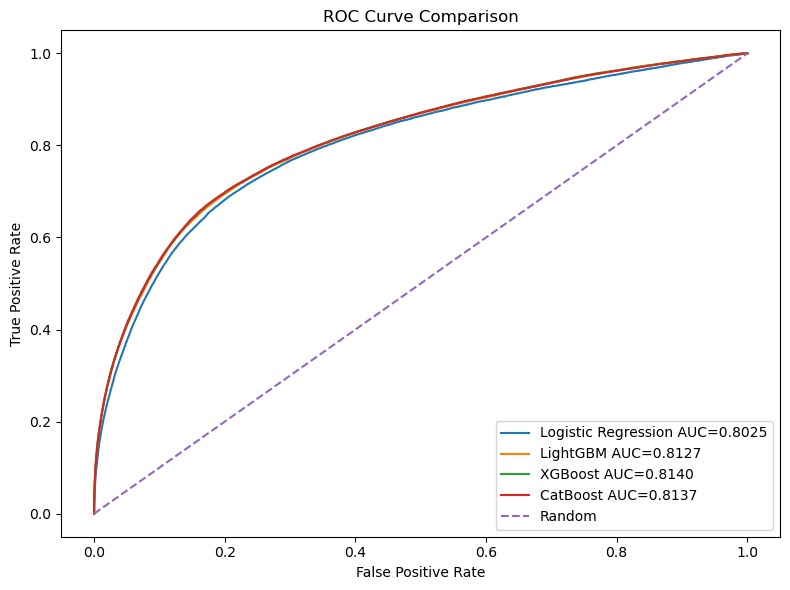

In [10]:
# 9. ROC 曲线
plt.figure(figsize=(8, 6))

for model_name, item in pred_results.items():
    pred_prob = item["pred_prob"]

    fpr, tpr, _ = roc_curve(y_test, pred_prob)
    auc_value = roc_auc_score(y_test, pred_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC={auc_value:.4f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/roc_curve_compare.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

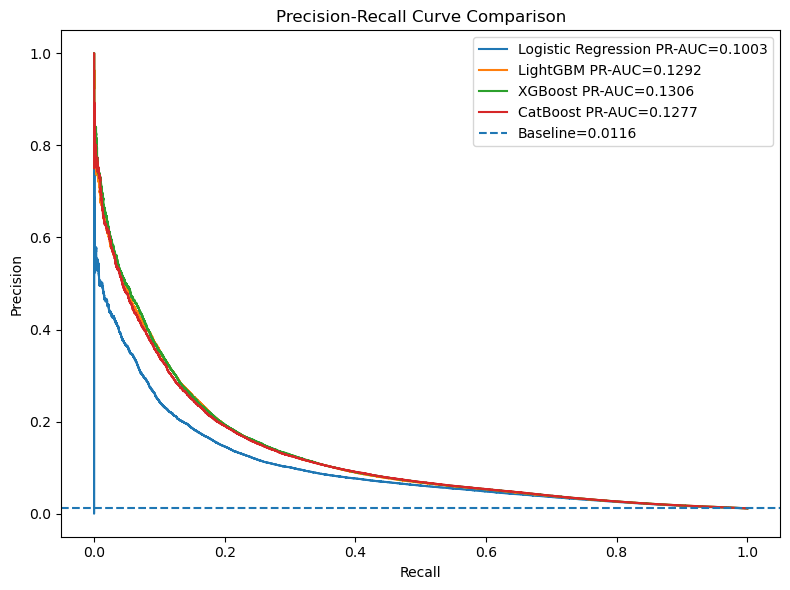

In [11]:
# 10. PR 曲线
# 在购买率很低的场景中，PR 曲线比 ROC 曲线更贴近业务问题。
plt.figure(figsize=(8, 6))

baseline_precision = y_test.mean()

for model_name, item in pred_results.items():
    pred_prob = item["pred_prob"]

    precision, recall, _ = precision_recall_curve(y_test, pred_prob)
    pr_auc_value = average_precision_score(y_test, pred_prob)

    plt.plot(
        recall,
        precision,
        label=f"{model_name} PR-AUC={pr_auc_value:.4f}"
    )

plt.axhline(
    baseline_precision,
    linestyle="--",
    label=f"Baseline={baseline_precision:.4f}"
)

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/pr_curve_compare.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

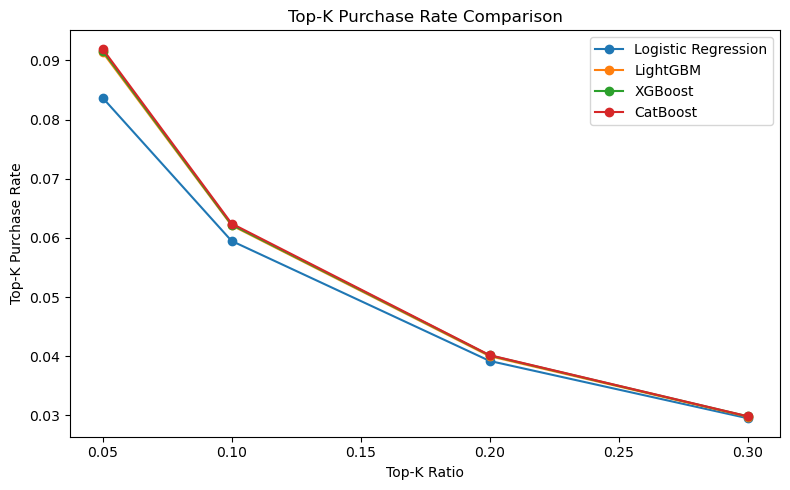

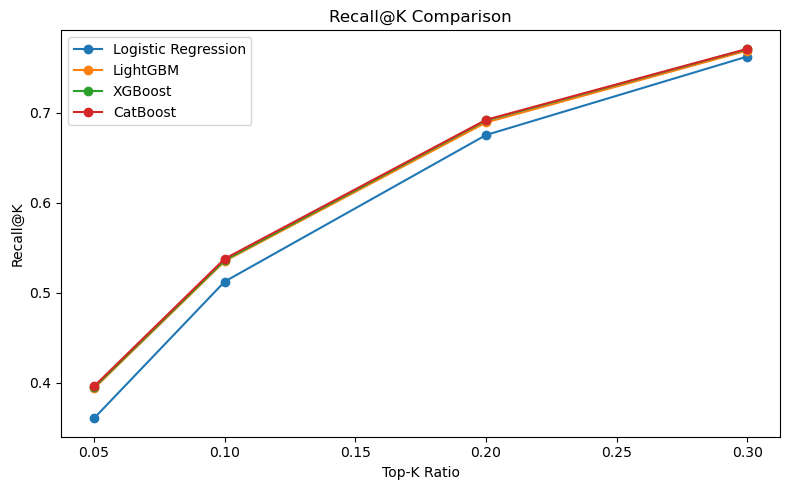

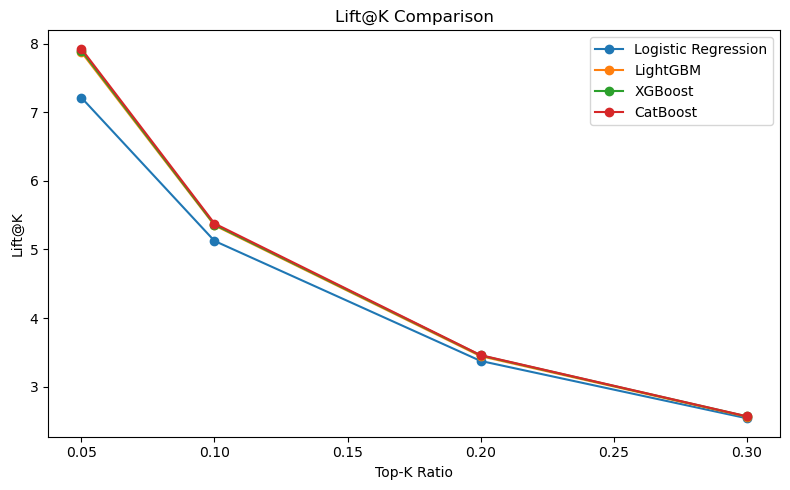

In [12]:
# 11. Top-K 指标可视化
# Top-K Purchase Rate
plt.figure(figsize=(8, 5))

for model_name in all_models_topk_results["model"].unique():
    temp = all_models_topk_results[
        all_models_topk_results["model"] == model_name
    ]

    plt.plot(
        temp["top_k"],
        temp["topk_purchase_rate"],
        marker="o",
        label=model_name
    )

plt.title("Top-K Purchase Rate Comparison")
plt.xlabel("Top-K Ratio")
plt.ylabel("Top-K Purchase Rate")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/topk_purchase_rate_compare.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Recall@K
plt.figure(figsize=(8, 5))

for model_name in all_models_topk_results["model"].unique():
    temp = all_models_topk_results[
        all_models_topk_results["model"] == model_name
    ]

    plt.plot(
        temp["top_k"],
        temp["recall_at_k"],
        marker="o",
        label=model_name
    )

plt.title("Recall@K Comparison")
plt.xlabel("Top-K Ratio")
plt.ylabel("Recall@K")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/recall_at_k_compare.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Lift@K
plt.figure(figsize=(8, 5))

for model_name in all_models_topk_results["model"].unique():
    temp = all_models_topk_results[
        all_models_topk_results["model"] == model_name
    ]

    plt.plot(
        temp["top_k"],
        temp["lift_at_k"],
        marker="o",
        label=model_name
    )

plt.title("Lift@K Comparison")
plt.xlabel("Top-K Ratio")
plt.ylabel("Lift@K")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/lift_at_k_compare.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# 12. 保存 CatBoost 模型和特征列
cat_model = pred_results["CatBoost"]["model"]

cat_model.save_model("../outputs/models/catboost_model.cbm")

with open("../outputs/models/feature_cols.json", "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

In [14]:
# 13. 预测排序收益模拟
def simulate_prediction_roi(
    y_true,
    pred_prob,
    model_name,
    topk_list,
    contact_cost=1.0,
    purchase_profit=100.0
):
    """
    基于普通转化预测模型的 Top-K 收益模拟。
    """

    data = pd.DataFrame({
        "label": np.array(y_true),
        "pred_prob": np.array(pred_prob)
    })

    data = data.sort_values(
        "pred_prob",
        ascending=False
    ).reset_index(drop=True)

    total_users = len(data)
    overall_purchase_rate = data["label"].mean()

    records = []

    for k in topk_list:
        top_n = max(1, int(total_users * k))
        top_df = data.head(top_n)

        top_purchase_count = top_df["label"].sum()
        top_purchase_rate = top_df["label"].mean()

        random_expected_purchase = top_n * overall_purchase_rate
        incremental_purchase_vs_random = top_purchase_count - random_expected_purchase

        gross_profit = top_purchase_count * purchase_profit
        total_contact_cost = top_n * contact_cost
        net_profit = gross_profit - total_contact_cost

        roi = (
            net_profit / total_contact_cost
            if total_contact_cost > 0
            else np.nan
        )

        records.append({
            "model": model_name,
            "top_k": k,
            "top_n": top_n,
            "overall_purchase_rate": overall_purchase_rate,
            "topk_purchase_rate": top_purchase_rate,
            "top_purchase_count": top_purchase_count,
            "random_expected_purchase": random_expected_purchase,
            "incremental_purchase_vs_random": incremental_purchase_vs_random,
            "contact_cost": contact_cost,
            "purchase_profit": purchase_profit,
            "gross_profit": gross_profit,
            "total_contact_cost": total_contact_cost,
            "net_profit": net_profit,
            "roi": roi
        })

    return pd.DataFrame(records)


roi_list = []

for model_name, item in pred_results.items():
    temp_roi = simulate_prediction_roi(
        y_true=y_test,
        pred_prob=item["pred_prob"],
        model_name=model_name,
        topk_list=topk_list,
        contact_cost=1.0,
        purchase_profit=100.0
    )

    roi_list.append(temp_roi)

prediction_roi_results = pd.concat(roi_list, ignore_index=True)

display(prediction_roi_results)

prediction_roi_results.to_csv(
    "../outputs/tables/prediction_roi_simulation.csv",
    index=False,
    encoding="utf-8-sig"
)

best_prediction_targeting_strategy = prediction_roi_results.sort_values(
    "net_profit",
    ascending=False
).head(1)

display(best_prediction_targeting_strategy)

best_prediction_targeting_strategy.to_csv(
    "../outputs/tables/best_prediction_targeting_strategy.csv",
    index=False,
    encoding="utf-8-sig"
)

,model,top_k,top_n,overall_purchase_rate,topk_purchase_rate,top_purchase_count,random_expected_purchase,incremental_purchase_vs_random,contact_cost,purchase_profit,gross_profit,total_contact_cost,net_profit,roi
0,Logistic Regression,0.05,158458,0.011608,0.083713,13265,1839.445357,11425.554643,1.0,100.0,1326500.0,158458.0,1168042.0,7.371303
1,Logistic Regression,0.10,316916,0.011608,0.059489,18853,3678.890713,15174.109287,1.0,100.0,1885300.0,316916.0,1568384.0,4.948895
2,Logistic Regression,0.20,633833,0.011608,0.039196,24844,7357.793035,17486.206965,1.0,100.0,2484400.0,633833.0,1850567.0,2.919644
3,Logistic Regression,0.30,950750,0.011608,0.029506,28053,11036.695357,17016.304643,1.0,100.0,2805300.0,950750.0,1854550.0,1.950618
4,LightGBM,0.05,158458,0.011608,0.091406,14484,1839.445357,12644.554643,1.0,100.0,1448400.0,158458.0,1289942.0,8.140592
5,LightGBM,0.10,316916,0.011608,0.062124,19688,3678.890713,16009.109287,1.0,100.0,1968800.0,316916.0,1651884.0,5.212372
6,LightGBM,0.20,633833,0.011608,0.040004,25356,7357.793035,17998.206965,1.0,100.0,2535600.0,633833.0,1901767.0,3.000423
7,LightGBM,0.30,950750,0.011608,0.029763,28297,11036.695357,17260.304643,1.0,100.0,2829700.0,950750.0,1878950.0,1.976282
8,XGBoost,0.05,158458,0.011608,0.091658,14524,1839.445357,12684.554643,1.0,100.0,1452400.0,158458.0,1293942.0,8.165836
9,XGBoost,0.10,316916,0.011608,0.062237,19724,3678.890713,16045.109287,1.0,100.0,1972400.0,316916.0,1655484.0,5.223731


,model,top_k,top_n,overall_purchase_rate,topk_purchase_rate,top_purchase_count,random_expected_purchase,incremental_purchase_vs_random,contact_cost,purchase_profit,gross_profit,total_contact_cost,net_profit,roi
14,CatBoost,0.2,633833,0.011608,0.040178,25466,7357.793035,18108.206965,1.0,100.0,2546600.0,633833.0,1912767.0,3.017778


## Top-K 业务指标解释

在真实电商营销场景中，平台通常不会对所有用户进行触达，而是会在预算约束下优先触达模型认为最有价值的一部分用户。

因此，Top-K 指标比单纯的准确率更符合业务目标：

- Top-K purchase rate 衡量模型筛选出的高分用户真实购买率；
- Recall@K 衡量 Top-K 用户覆盖了多少真实购买用户；
- Lift@K 衡量 Top-K 用户购买率相对于整体购买率的提升倍数。

如果某个模型在 Top-K purchase rate 上表现更好，说明它更适合用于精准营销、优惠券投放和高价值用户运营。

# 本节小结

1. 本 notebook 比较了 Logistic Regression、LightGBM、XGBoost 和 CatBoost。
2. 由于购买用户占比较低，Accuracy 不是核心指标。
3. AUC / PR-AUC 用于衡量模型整体排序和少数类识别能力。
4. Top-K purchase rate、Recall@K 和 Lift@K 更贴近有限预算投放场景。
5. 最终模型选择应结合业务指标，而不是只看单一统计指标。
6. 本节 ROI 是预测排序收益模拟，不等同于严格因果增量 ROI。